In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("smartcart_customers.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [5]:
df["Age"] = 2026-df["Year_Birth"]
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"] , dayfirst = True)
reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"]=(reference_date - df["Dt_Customer"]).dt.days

In [6]:
df["Total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [7]:
df["Total_children"] = df["Kidhome"] + df["Teenhome"]

In [8]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [9]:
df["Education"] = df["Education"].replace({"Basic" : "UG" , "2n Cycle" : "UG" , "Graduation" : "Graduate" , "Master" : "PG" ,"PhD" : "PG"})

In [10]:
df["Education"].value_counts()

Education
Graduate    1127
PG           856
UG           257
Name: count, dtype: int64

In [11]:
df["Living_With"] = df["Marital_Status"].replace({"Married" : "Partner" , "Together" : "Partner" , "Single" : "Alone" , "Divorced" : "Alone" , "Widow" : "Alone" , "Absurd" : "Alone" , "YOLO" : "Alone"})
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [12]:
cols = ["ID" , "Year_Birth" , "Kidhome" , "Teenhome" , "Dt_Customer"]
spending_cols = ["MntWines" ,  "MntFruits" , "MntMeatProducts" , "MntFishProducts" , "MntSweetProducts" , "MntGoldProds"]
cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns = cols_to_drop)

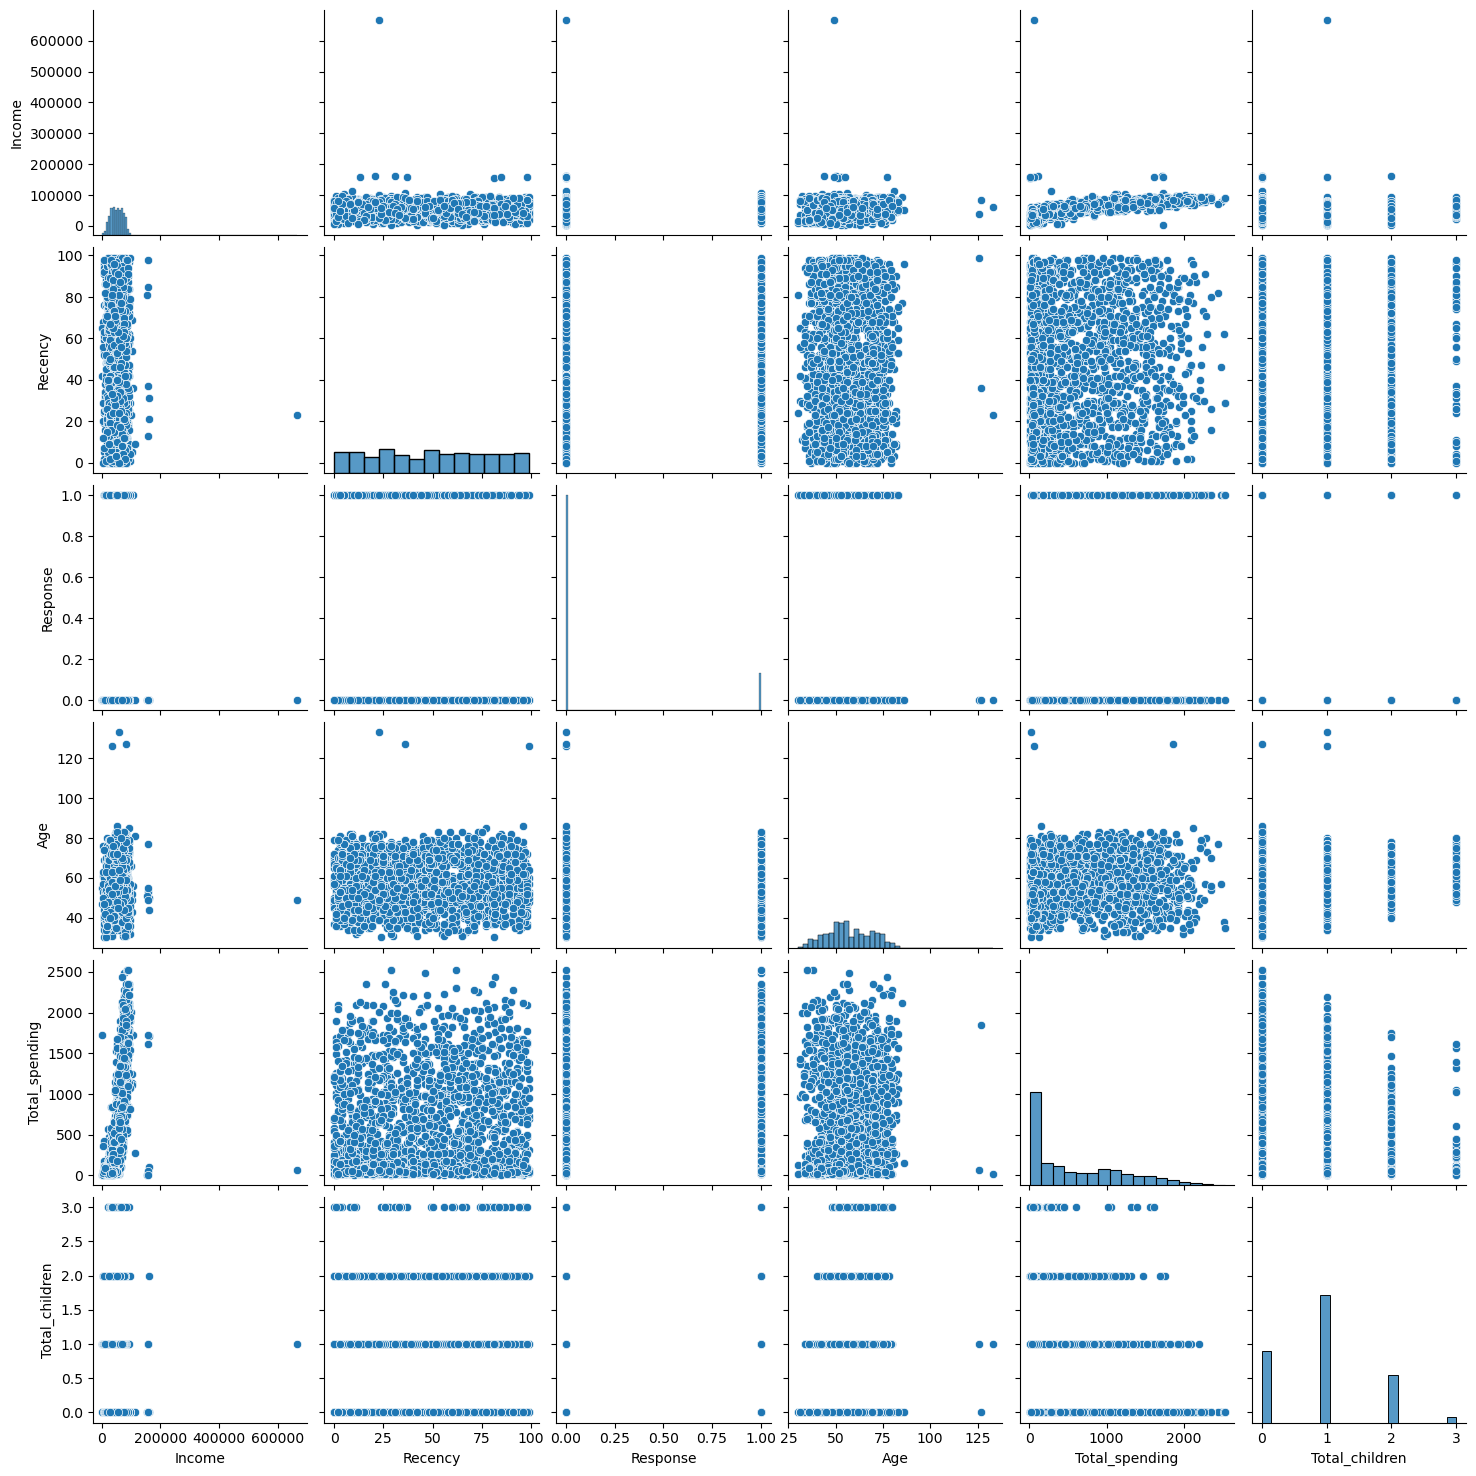

In [13]:
cols = ["Income" , "Recency" , "Response" , "Age" , "Total_spending" , "Total_children"]
sns.pairplot(df_cleaned[cols])

In [14]:
print("Data WITH Outliers : " , len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000)]
print("Data WITHOUT Outliers : " , len(df_cleaned)) 

Data WITH Outliers :  2240
Data WITHOUT Outliers :  2236


<Axes: >

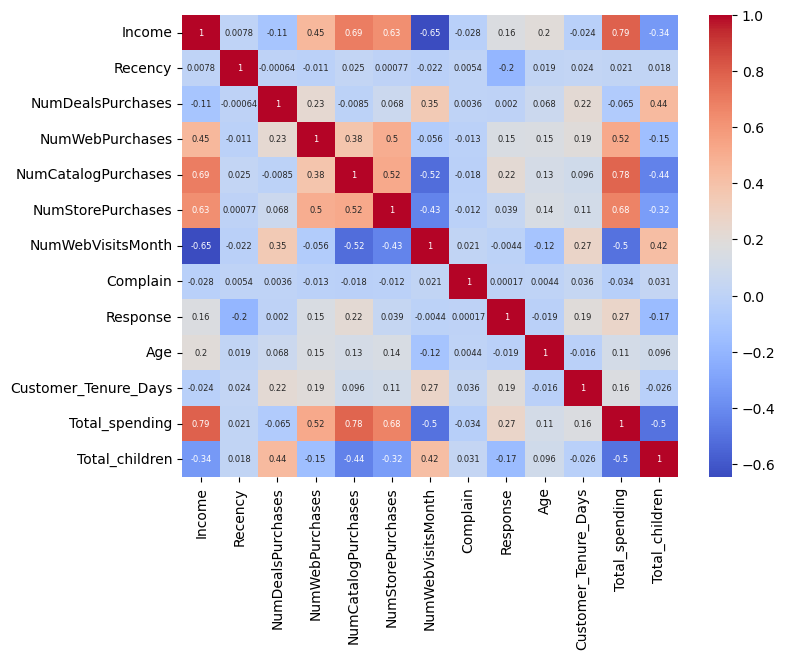

In [15]:
correlation = df_cleaned.corr(numeric_only = True)
plt.figure(figsize = (8,6))
sns.heatmap(correlation , annot = True , annot_kws = {"size" : 6} , cmap = "coolwarm")

In [16]:
from sklearn.preprocessing import OneHotEncoder
one = OneHotEncoder()
cat_cols = ["Education" , "Living_With" , "Marital_Status"]
enc_cols = one.fit_transform(df_cleaned[cat_cols])
enc_df = pd.DataFrame(enc_cols.toarray() , columns = one.get_feature_names_out(cat_cols) , index = df_cleaned.index)
enc_df.head()
df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols) , enc_df] , axis = 1)

In [17]:
from sklearn.preprocessing import StandardScaler
X = df_encoded
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Text(0.5, 0.92, '3d Projection')

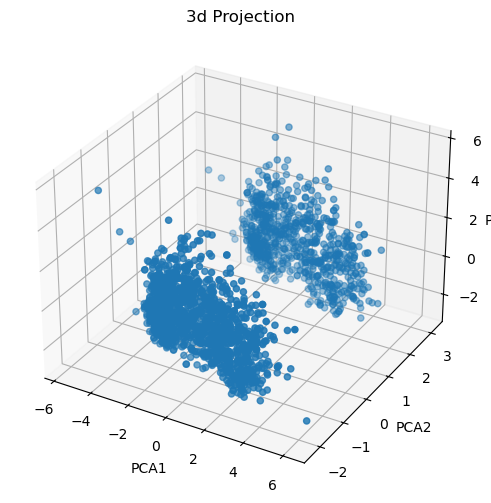

In [18]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111 , projection = "3d")
ax.scatter(X_pca[: , 0] , X_pca[: , 1] , X_pca[: , 2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d Projection")

Best k =  5


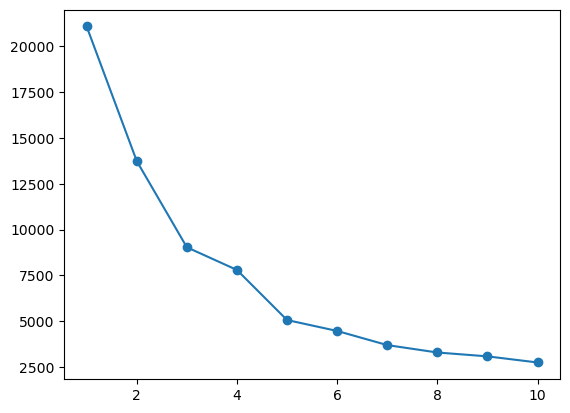

In [19]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,11):
    kmeans = KMeans(n_clusters = k , random_state = 42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)
knee = KneeLocator(range(1,11) , wcss , curve = "convex" , direction = "decreasing")
optimal_k = knee.elbow
print("Best k = " , optimal_k)
plt.plot(range(1,11) , wcss , marker ='o')

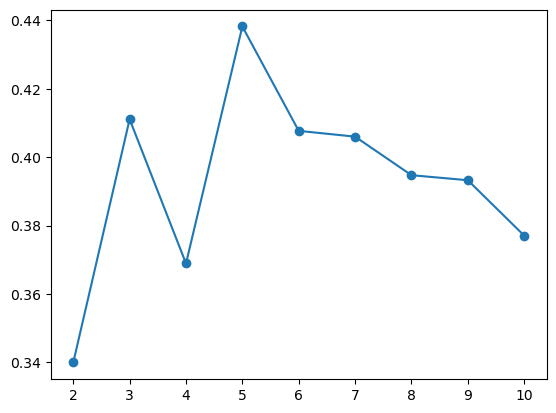

In [20]:
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
    kmeans = KMeans(n_clusters = k , random_state = 42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca , labels)
    scores.append(score)
plt.plot(range(2,11) , scores , marker = 'o')

Text(0, 0.5, 'SS')

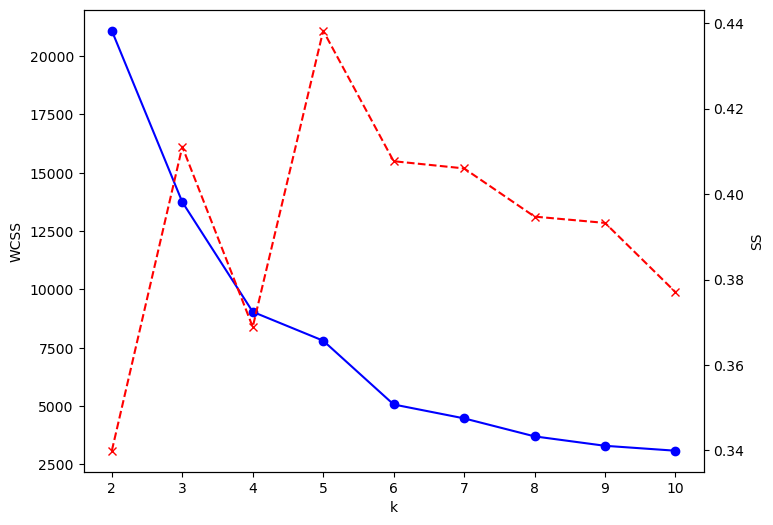

In [21]:
k_range = range(2,11)
fig , ax1 = plt.subplots(figsize = (8,6))
ax1.plot(k_range , wcss[:len(k_range)] , marker = 'o' , color = "blue")
ax1.set_xlabel("k")
ax1.set_ylabel("WCSS")
ax2 = ax1.twinx()
ax2.plot(k_range , scores[:len(k_range)] , marker = 'x' , color = "red" , linestyle = "--")
ax2.set_ylabel("SS")

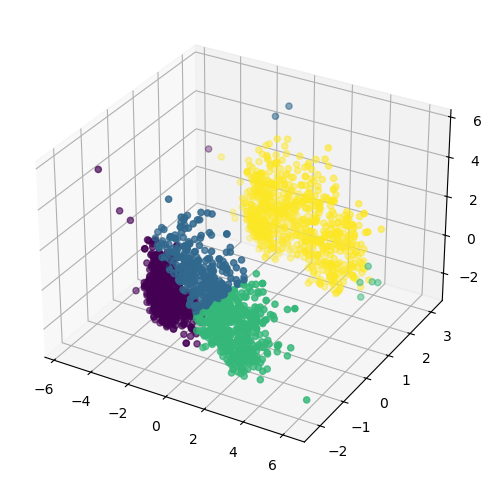

In [22]:
kmeans = KMeans(n_clusters = 4 , random_state = 42)
labels_kmeans = kmeans.fit_predict(X_pca)
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111 , projection = "3d")
ax.scatter(X_pca[: , 0] , X_pca[: , 1] , X_pca[: , 2] , c=labels_kmeans)

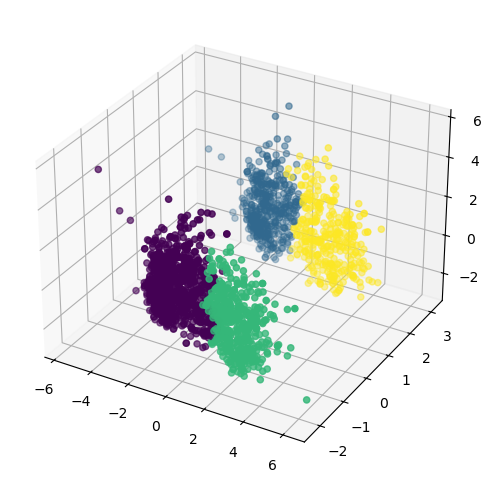

In [23]:
from sklearn.cluster import AgglomerativeClustering
agg_clf = AgglomerativeClustering(n_clusters = 4 , linkage = "ward")
labels_agg = agg_clf.fit_predict(X_pca)
fig = plt.figure(figsize =(8,6))
ax = fig.add_subplot(111,projection = "3d")
ax.scatter(X_pca[: , 0] , X_pca[: , 1] , X_pca[: , 2] , c=labels_agg)

<Axes: xlabel='cluster', ylabel='count'>

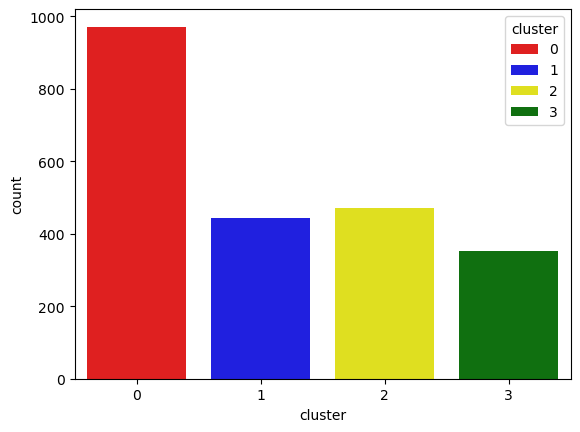

In [24]:
X["cluster"] = labels_agg
ppl = ["red" , "blue" , "yellow" , "green"]
sns.countplot(x=X["cluster"] , palette = ppl , hue = X["cluster"])

In [25]:
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        40981.131823  49.230690           2.635427         3.292482   
1        37243.163657  48.665914           2.550790         2.790068   
2        74340.683652  48.645435           1.806794         5.721868   
3        70826.730769  50.000000           1.883191         5.732194   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   1.121524           4.382080           6.270855  0.011329   
1                   0.848758           3.668172           6.564334  0.011287   
2                   5.783439           8.747346           3.375796  0.004246   
3                   5.031339           8.430199           3.720798  0.005698   

         Response        Age  ...  Living_With_Alone  Living_With_Partner  \
cluster  